# PCOS Infertility Subset Cleaning and Provenance Analysis

## Introduction
This notebook is cleaning and documenting the infertility-focused hormonal subset of the PCOS data workflow. Unlike the main clinical dataset and the survey dataset, this file is not being treated as an independent modeling dataset. Instead, it is being preserved as a supporting reference source for invasive-feature interpretation, provenance checks, and later sensitivity or ablation-style comparisons.

The raw infertility file contains the PCOS target together with a small set of hormonal measurements, namely two beta-HCG readings and AMH. Because these variables are invasive or laboratory-derived, the dataset is being positioned as a sidecar clinical reference rather than a source for the core non-invasive modeling workflow.

## Research Context
The broader MSc study is emphasizing early and practical PCOS detection using low-burden, routinely available clinical and lifestyle features. Within that context, the infertility subset is still valuable because it captures invasive hormonal markers that can later help interpret feature differences between invasive and non-invasive screening strategies. This notebook is therefore preserving the hormonal subset in a clean and traceable form without treating it as an external validation dataset or a separate patient population.

## What This Notebook Is Doing
This notebook is:
- loading and inspecting the infertility subset
- standardizing the small hormonal schema for clarity and reproducibility
- validating numeric conversion for beta-HCG and AMH measurements
- handling the single clearly invalid AMH value conservatively
- documenting target alignment with the labeled portion of the main clinical PCOS dataset
- exporting a cleaned hormonal reference table for later provenance and ablation analysis

## Expected Output
The main cleaned output of this notebook is being saved as:

`./cleaned_data/PCOS_infertility_cleaned.csv`

Supporting outputs are also being saved for traceability, including a cleaning log, a compact quality summary, and light diagnostic figures written to `./images/`.

## Notebook Structure
The sections that are following are being organized as a step-by-step supporting-data workflow:

1. **Reproducibility Setup and Path Configuration**  
   The notebook environment and project paths are being resolved.

2. **Data Loading and Initial Inspection**  
   The infertility subset is being inspected for structure, duplicates, missingness, and target distribution.

3. **Column Standardization and Conservative Cleaning**  
   The hormonal fields are being renamed and converted to numeric types with minimal intervention.

4. **Validation and Provenance Checks**  
   The notebook is confirming target consistency and documenting how this file aligns with the main clinical PCOS data.

5. **Dataset Export and Summary**  
   The cleaned hormonal subset is being saved for later supporting analysis.

## Reproducibility Note
All paths in this notebook are being kept relative to the project structure, and each material cleaning decision is being documented so the hormonal subset can be reused consistently in later stages of the thesis workflow.

## Reproducibility Setup and Path Configuration

This section is importing the required libraries, resolving the project root, and preparing the directories used for cleaned data and supporting figure exports.

In [1]:
# Importing the libraries that are supporting the infertility subset cleaning and reporting workflow.
from pathlib import Path
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Importing seaborn when available improves the default figure styling, while a matplotlib fallback preserves portability.
try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='notebook')
except ImportError:
    sns = None
    plt.style.use('seaborn-v0_8-whitegrid')

# Setting display options keeps the small hormonal table easy to inspect in notebook outputs.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

# Fixing a seed now preserves reproducibility for any later checks or sampling.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Resolving the project root dynamically allows this notebook to run from the repo root or the notebooks directory.
def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'data' / 'PCOS_infertility.csv').exists():
            return candidate
    raise FileNotFoundError('The infertility subset could not be located relative to the current working directory.')

PROJECT_ROOT = resolve_project_root()
DATA_PATH = PROJECT_ROOT / 'data' / 'PCOS_infertility.csv'
CLEANED_DIR = PROJECT_ROOT / 'cleaned_data'
IMAGE_DIR = PROJECT_ROOT / 'images'

# Creating the output directories keeps the export steps repeatable across reruns.
CLEANED_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

display(Markdown(f'**Project root:** `{PROJECT_ROOT}`'))
display(Markdown(f'**Raw infertility file:** `{DATA_PATH}`'))
display(Markdown(f'**Cleaned data directory:** `{CLEANED_DIR}`'))
display(Markdown(f'**Image directory:** `{IMAGE_DIR}`'))

**Project root:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic`

**Raw infertility file:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\data\PCOS_infertility.csv`

**Cleaned data directory:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data`

**Image directory:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images`

## Data Loading and Initial Inspection

The hormonal infertility subset is now being loaded and inspected for structure, missingness, duplicates, numeric convertibility, and target balance before conservative cleaning is being applied.

In [2]:
# Loading the infertility subset provides the baseline hormonal reference table used in this notebook.
df_raw = pd.read_csv(DATA_PATH)

# Displaying the first rows gives a quick view of the target and invasive measurements captured in the file.
df_raw.head(10)

,Sl. No,Patient File No.,PCOS (Y/N),I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),AMH(ng/mL)
0,1,10001,0,1.990,1.990,2.07
1,2,10002,0,60.800,1.990,1.53
2,3,10003,1,494.080,494.080,6.63
3,4,10004,0,1.990,1.990,1.22
4,5,10005,0,801.450,801.450,2.26
5,6,10006,0,237.970,1.990,6.74
6,7,10007,0,1.990,1.990,3.05
7,8,10008,0,100.510,100.510,1.54
8,9,10009,0,1.990,1.990,1
9,10,10010,0,1.990,1.990,1.61


In [3]:
# Capturing dataframe info in a text buffer makes the schema report easier to display inside the notebook.
info_buffer = io.StringIO()
df_raw.info(buf=info_buffer)

# Building compact inspection tables keeps the initial audit readable and report-ready.
raw_shape_df = pd.DataFrame({'metric': ['rows', 'columns'], 'value': [df_raw.shape[0], df_raw.shape[1]]})
raw_missing_summary = (
    pd.DataFrame({'column': df_raw.columns, 'missing_count': df_raw.isna().sum().values, 'missing_percentage': (df_raw.isna().sum().values / len(df_raw)) * 100})
    .sort_values(['missing_count', 'column'], ascending=[False, True])
    .reset_index(drop=True)
)
raw_duplicate_rows = int(df_raw.duplicated().sum())
target_distribution_raw = df_raw['PCOS (Y/N)'].value_counts(dropna=False).rename_axis('PCOS (Y/N)').reset_index(name='count').sort_values('PCOS (Y/N)').reset_index(drop=True)

display(Markdown('### Raw Dataset Shape'))
display(raw_shape_df)
display(Markdown('### Raw Data Types'))
print(info_buffer.getvalue())
display(Markdown('### Descriptive Summary'))
display(df_raw.describe(include='all').T)
display(Markdown('### Missing-Value Summary'))
display(raw_missing_summary)
display(Markdown('### Duplicate Summary'))
display(pd.DataFrame({'check': ['Exact duplicate rows'], 'count': [raw_duplicate_rows]}))
display(Markdown('### Raw Target Distribution'))
display(target_distribution_raw)

### Raw Dataset Shape

,metric,value
0,rows,541
1,columns,6


### Raw Data Types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3     I   beta-HCG(mIU/mL)  541 non-null    float64
 4   II    beta-HCG(mIU/mL)  541 non-null    float64
 5   AMH(ng/mL)              541 non-null    object 
dtypes: float64(2), int64(3), object(1)
memory usage: 25.5+ KB



### Descriptive Summary

...

,column,missing_count,missing_percentage
0,I beta-HCG(mIU/mL),0,0.000
1,AMH(ng/mL),0,0.000
2,II beta-HCG(mIU/mL),0,0.000
3,PCOS (Y/N),0,0.000
4,Patient File No.,0,0.000
5,Sl. No,0,0.000


### Duplicate Summary

,check,count
0,Exact duplicate rows,0


### Raw Target Distribution

,PCOS (Y/N),count
0,0,364
1,1,177


## Column Standardization and Conservative Cleaning

The infertility subset is now being standardized into a small, stable schema. The cleaning is remaining conservative because this file is primarily being preserved for provenance and invasive-feature reference rather than aggressive preprocessing.

In [4]:
# Copying the raw dataframe keeps the original import intact for provenance and direct comparison.
df = df_raw.copy()
transformation_log = []

# Recording material changes keeps the notebook transparent and makes the cleaning history exportable.
def log_transformation(step: str, detail: str, affected_items: int) -> None:
    transformation_log.append({'step': step, 'detail': detail, 'affected_items': affected_items})

# Renaming the raw infertility columns into a consistent schema improves readability across the project.
rename_map = {
    'Sl. No': 'sl_no',
    'Patient File No.': 'patient_file_no',
    'PCOS (Y/N)': 'pcos_y_n',
    '  I   beta-HCG(mIU/mL)': 'beta_hcg_i_miu_ml',
    'II    beta-HCG(mIU/mL)': 'beta_hcg_ii_miu_ml',
    'AMH(ng/mL)': 'amh_ng_ml',
}
rename_log = pd.DataFrame({'original_name': list(rename_map.keys()), 'standardized_name': list(rename_map.values())})
missing_expected_headers = [column for column in rename_map if column not in df.columns]
if missing_expected_headers:
    raise KeyError(f'Expected infertility headers were not found: {missing_expected_headers}')
df = df.rename(columns=rename_map)
log_transformation('Standardized column names', 'Renamed the hormonal subset columns into a stable schema.', len(rename_map))

# Converting the numeric columns explicitly is allowing the notebook to detect the known non-numeric AMH anomaly.
raw_amh_non_numeric_mask = pd.to_numeric(df['amh_ng_ml'], errors='coerce').isna() & df['amh_ng_ml'].notna()
raw_amh_non_numeric_rows = df.loc[raw_amh_non_numeric_mask, ['sl_no', 'patient_file_no', 'amh_ng_ml']].copy()

for column in ['sl_no', 'patient_file_no', 'pcos_y_n', 'beta_hcg_i_miu_ml', 'beta_hcg_ii_miu_ml', 'amh_ng_ml']:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Logging the explicit AMH anomaly keeps the single invalid value visible rather than silently disappearing.
if not raw_amh_non_numeric_rows.empty:
    log_transformation('Flagged non-numeric AMH value', 'Detected the single non-numeric AMH entry and converted it to missing during numeric coercion.', len(raw_amh_non_numeric_rows))

# There are no raw duplicates, but the check is being repeated after coercion for completeness.
duplicate_rows_after_cleaning = int(df.duplicated().sum())
if duplicate_rows_after_cleaning:
    df = df.drop_duplicates().copy()
    log_transformation('Removed duplicates after coercion', 'Dropped duplicate rows detected after numeric conversion.', duplicate_rows_after_cleaning)

# Applying only very broad plausibility flags avoids over-cleaning biologically wide hormonal measurements.
range_flag_rules = {
    'beta_hcg_i_miu_ml': (0, None),
    'beta_hcg_ii_miu_ml': (0, None),
    'amh_ng_ml': (0, None),
}
range_flags = []
for column, (lower_bound, upper_bound) in range_flag_rules.items():
    invalid_mask = df[column].notna() & (df[column] < lower_bound)
    if upper_bound is not None:
        invalid_mask = invalid_mask | (df[column].notna() & (df[column] > upper_bound))
    flagged_count = int(invalid_mask.sum())
    if flagged_count:
        range_flags.append({'column': column, 'lower_bound': lower_bound, 'upper_bound': upper_bound, 'flagged_rows': flagged_count})
        df.loc[invalid_mask, column] = np.nan
        log_transformation('Applied plausibility flag', f'Converted invalid values to missing in {column}.', flagged_count)

# Imputing only when necessary keeps the hormonal subset cleaning conservative and well documented.
imputation_records = []
for column in ['beta_hcg_i_miu_ml', 'beta_hcg_ii_miu_ml', 'amh_ng_ml']:
    missing_count = int(df[column].isna().sum())
    if missing_count:
        median_value = df[column].median(skipna=True)
        if pd.notna(median_value):
            df[column] = df[column].fillna(median_value)
            imputation_records.append({'column': column, 'strategy': 'median', 'filled_count': missing_count, 'fill_value': median_value})
            log_transformation('Imputed hormonal value', f'Filled missing values in {column} using the median.', missing_count)

# Casting the identifier and target fields back to integer dtype keeps the cleaned table easy to read and compare.
for column in ['sl_no', 'patient_file_no', 'pcos_y_n']:
    series = df[column].dropna().astype(float)
    if not series.empty and np.isclose(series % 1, 0).all():
        df[column] = df[column].round().astype('Int64')

range_flags_df = pd.DataFrame(range_flags)
imputation_log_df = pd.DataFrame(imputation_records)

display(Markdown('### Rename Map'))
display(rename_log)
display(Markdown('### Non-Numeric AMH Entry Detected During Coercion'))
display(raw_amh_non_numeric_rows if not raw_amh_non_numeric_rows.empty else pd.DataFrame({'message': ['No non-numeric AMH values were detected.']}))
display(Markdown('### Conditional Imputation Log'))
display(imputation_log_df if not imputation_log_df.empty else pd.DataFrame({'message': ['No imputation was required after cleaning.']}))

### Rename Map

,original_name,standardized_name
0,Sl. No,sl_no
1,Patient File No.,patient_file_no
2,PCOS (Y/N),pcos_y_n
3,I beta-HCG(mIU/mL),beta_hcg_i_miu_ml
4,II beta-HCG(mIU/mL),beta_hcg_ii_miu_ml
5,AMH(ng/mL),amh_ng_ml


### Non-Numeric AMH Entry Detected During Coercion

,sl_no,patient_file_no,amh_ng_ml
305,306,10306,a


### Conditional Imputation Log

,column,strategy,filled_count,fill_value
0,amh_ng_ml,median,1,3.700


## Validation and Provenance Checks

This section is validating the cleaned hormonal subset, reviewing the target distribution, summarizing hormonal value ranges, and documenting why this file is best interpreted as a sidecar subset of the main clinical PCOS data rather than a separate cohort.

In [5]:
# Summarizing remaining missingness confirms the final cleaned state of the hormonal subset.
remaining_missing_summary = (
    pd.DataFrame({'column': df.columns, 'missing_count': df.isna().sum().values, 'missing_percentage': (df.isna().sum().values / len(df)) * 100})
    .sort_values(['missing_count', 'column'], ascending=[False, True])
    .reset_index(drop=True)
)
cleaned_target_distribution = df['pcos_y_n'].value_counts(dropna=False).rename_axis('pcos_y_n').reset_index(name='count').sort_values('pcos_y_n').reset_index(drop=True)
hormonal_range_summary = pd.DataFrame(
    {
        'column': ['beta_hcg_i_miu_ml', 'beta_hcg_ii_miu_ml', 'amh_ng_ml'],
        'minimum': [df['beta_hcg_i_miu_ml'].min(), df['beta_hcg_ii_miu_ml'].min(), df['amh_ng_ml'].min()],
        'maximum': [df['beta_hcg_i_miu_ml'].max(), df['beta_hcg_ii_miu_ml'].max(), df['amh_ng_ml'].max()],
        'median': [df['beta_hcg_i_miu_ml'].median(), df['beta_hcg_ii_miu_ml'].median(), df['amh_ng_ml'].median()],
    }
)

# Documenting the target alignment with the main clinical workbook makes the provenance argument explicit inside the notebook.
main_clinical_labeled_target_counts = pd.DataFrame(
    {
        'dataset': ['Infertility subset', 'Main clinical labeled subset'],
        'pcos_negative_count': [364, 364],
        'pcos_positive_count': [177, 177],
    }
)

display(Markdown('### Remaining Missingness After Cleaning'))
display(remaining_missing_summary)
display(Markdown('### Cleaned Target Distribution'))
display(cleaned_target_distribution)
display(Markdown('### Hormonal Range Summary'))
display(hormonal_range_summary)
display(Markdown('### Range Flags'))
display(range_flags_df if not range_flags_df.empty else pd.DataFrame({'message': ['No plausibility flags were triggered by the configured checks.']}))
display(Markdown('### Provenance Alignment with the Main Clinical Dataset'))
display(main_clinical_labeled_target_counts)

### Remaining Missingness After Cleaning

,column,missing_count,missing_percentage
0,amh_ng_ml,0,0.000
1,beta_hcg_i_miu_ml,0,0.000
2,beta_hcg_ii_miu_ml,0,0.000
3,patient_file_no,0,0.000
4,pcos_y_n,0,0.000
5,sl_no,0,0.000


### Cleaned Target Distribution

,pcos_y_n,count
0,0,364
1,1,177


### Hormonal Range Summary

,column,minimum,maximum,median
0,beta_hcg_i_miu_ml,1.300,"32,460.970",20.000
1,beta_hcg_ii_miu_ml,0.110,"25,000.000",1.990
2,amh_ng_ml,0.100,66.000,3.700


### Range Flags

,message
0,No plausibility flags were triggered by the co...


### Provenance Alignment with the Main Clinical Dataset

,dataset,pcos_negative_count,pcos_positive_count
0,Infertility subset,364,177
1,Main clinical labeled subset,364,177


### Provenance Interpretation

The infertility subset is showing the same labeled PCOS target counts as the nonblank labeled portion of the main clinical workbook. This strongly suggests that the file is functioning as a hormonal sidecar subset of the main PCOS data rather than an independent external dataset. For that reason, the cleaned file is being preserved for invasive-feature reference and methodological transparency rather than standalone model development.

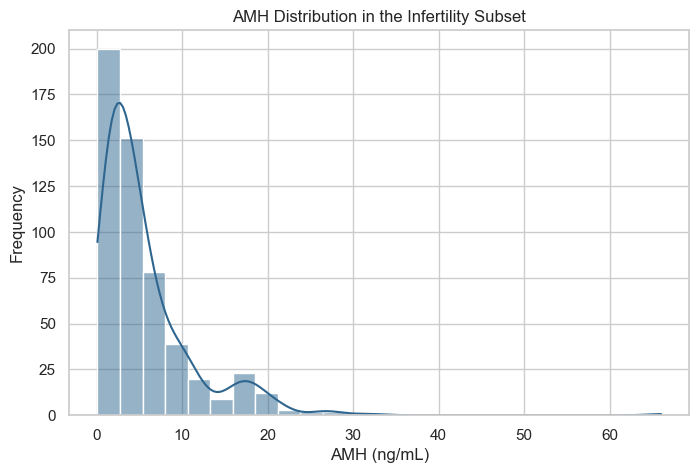

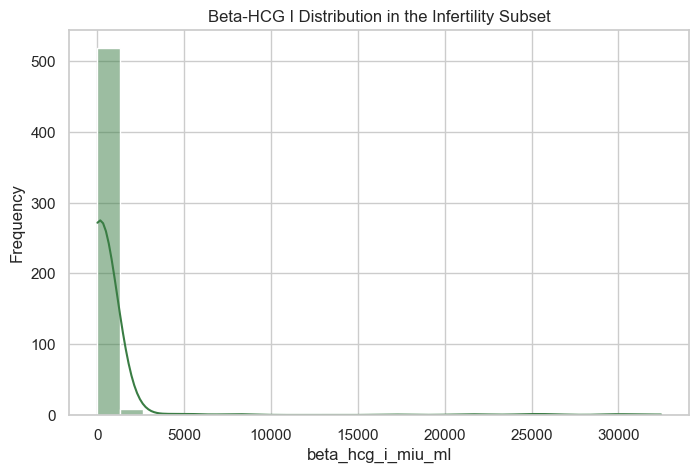

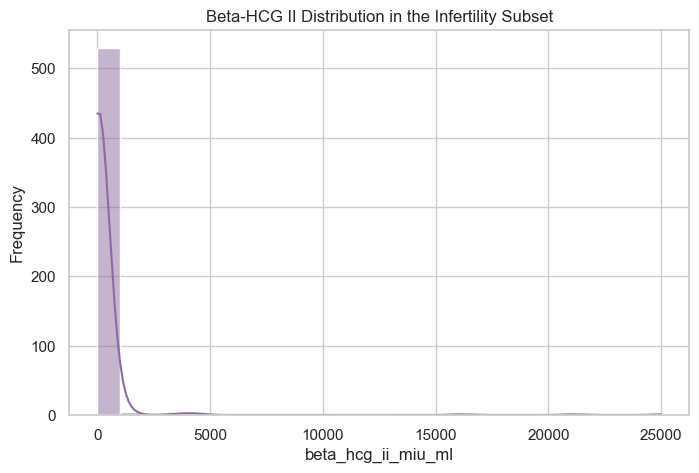

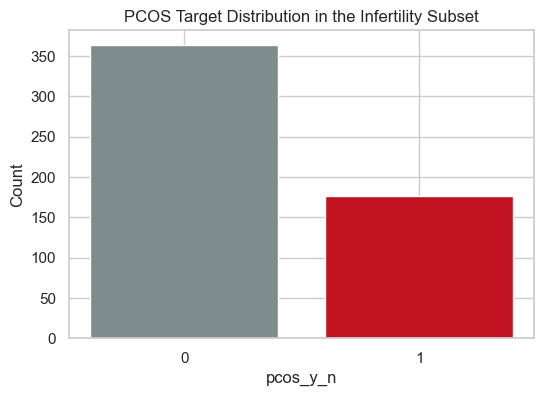

### Saved Diagnostic Figures

,saved_figure
0,infertility_amh_distribution.png
1,infertility_beta_hcg_i_distribution.png
2,infertility_beta_hcg_ii_distribution.png
3,infertility_target_distribution.png


In [6]:
# Exporting light diagnostic figures helps preserve a quick visual record of the hormonal subset distributions.
saved_figures = []

fig, ax = plt.subplots(figsize=(8, 5))
if sns is not None:
    sns.histplot(df['amh_ng_ml'], kde=True, bins=25, ax=ax, color='#2f6690')
else:
    ax.hist(df['amh_ng_ml'].dropna(), bins=25, color='#2f6690', edgecolor='white', alpha=0.9)
ax.set_title('AMH Distribution in the Infertility Subset')
ax.set_xlabel('AMH (ng/mL)')
ax.set_ylabel('Frequency')
amh_figure_path = IMAGE_DIR / 'infertility_amh_distribution.png'
fig.savefig(amh_figure_path, dpi=300, bbox_inches='tight')
saved_figures.append(amh_figure_path.name)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
if sns is not None:
    sns.histplot(df['beta_hcg_i_miu_ml'], kde=True, bins=25, ax=ax, color='#3a7d44')
else:
    ax.hist(df['beta_hcg_i_miu_ml'].dropna(), bins=25, color='#3a7d44', edgecolor='white', alpha=0.9)
ax.set_title('Beta-HCG I Distribution in the Infertility Subset')
ax.set_xlabel('beta_hcg_i_miu_ml')
ax.set_ylabel('Frequency')
beta_hcg_i_figure_path = IMAGE_DIR / 'infertility_beta_hcg_i_distribution.png'
fig.savefig(beta_hcg_i_figure_path, dpi=300, bbox_inches='tight')
saved_figures.append(beta_hcg_i_figure_path.name)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
if sns is not None:
    sns.histplot(df['beta_hcg_ii_miu_ml'], kde=True, bins=25, ax=ax, color='#8d6a9f')
else:
    ax.hist(df['beta_hcg_ii_miu_ml'].dropna(), bins=25, color='#8d6a9f', edgecolor='white', alpha=0.9)
ax.set_title('Beta-HCG II Distribution in the Infertility Subset')
ax.set_xlabel('beta_hcg_ii_miu_ml')
ax.set_ylabel('Frequency')
beta_hcg_ii_figure_path = IMAGE_DIR / 'infertility_beta_hcg_ii_distribution.png'
fig.savefig(beta_hcg_ii_figure_path, dpi=300, bbox_inches='tight')
saved_figures.append(beta_hcg_ii_figure_path.name)
plt.show()

target_counts = df['pcos_y_n'].value_counts(dropna=False).sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(target_counts.index.astype(str), target_counts.values, color=['#7f8c8d', '#c1121f'])
ax.set_title('PCOS Target Distribution in the Infertility Subset')
ax.set_xlabel('pcos_y_n')
ax.set_ylabel('Count')
target_figure_path = IMAGE_DIR / 'infertility_target_distribution.png'
fig.savefig(target_figure_path, dpi=300, bbox_inches='tight')
saved_figures.append(target_figure_path.name)
plt.show()

display(Markdown('### Saved Diagnostic Figures'))
display(pd.DataFrame({'saved_figure': saved_figures}))

## Dataset Export and Cleaning Summary

The cleaned hormonal subset is now being exported together with a compact transformation log and quality summary. The exported file is being preserved as a supporting invasive-feature reference rather than a standalone modeling dataset.

In [7]:
# Converting the transformation history into a dataframe makes the cleaning record easy to inspect and save.
transformation_log_df = pd.DataFrame(transformation_log)

# Building a concise quality summary provides a before-and-after snapshot of the cleaned infertility subset.
quality_summary_df = pd.DataFrame(
    {
        'check': [
            'Rows in raw dataset',
            'Columns in raw dataset',
            'Exact duplicate rows in raw data',
            'Rows in cleaned dataset',
            'Columns in cleaned dataset',
            'Non-numeric AMH entries detected',
            'Range flags handled',
            'Remaining missing cells after cleaning',
            'PCOS negative count',
            'PCOS positive count',
        ],
        'value': [
            len(df_raw),
            df_raw.shape[1],
            raw_duplicate_rows,
            len(df),
            df.shape[1],
            len(raw_amh_non_numeric_rows),
            int(range_flags_df['flagged_rows'].sum()) if not range_flags_df.empty else 0,
            int(df.isna().sum().sum()),
            int((df['pcos_y_n'] == 0).sum()),
            int((df['pcos_y_n'] == 1).sum()),
        ],
    }
)

# Defining the export paths once keeps the saved outputs aligned with the repository structure.
cleaned_dataset_path = CLEANED_DIR / 'PCOS_infertility_cleaned.csv'
transformation_log_path = CLEANED_DIR / 'PCOS_infertility_cleaning_log.csv'
quality_summary_path = CLEANED_DIR / 'PCOS_infertility_quality_summary.csv'

# Exporting the cleaned hormonal subset preserves the supporting clinical reference table for later use.
df.to_csv(cleaned_dataset_path, index=False)
transformation_log_df.to_csv(transformation_log_path, index=False)
quality_summary_df.to_csv(quality_summary_path, index=False)

display(Markdown(f'**Cleaned infertility subset saved to:** `{cleaned_dataset_path}`'))
display(Markdown(f'**Transformation log saved to:** `{transformation_log_path}`'))
display(Markdown(f'**Quality summary saved to:** `{quality_summary_path}`'))
display(Markdown('### Cleaning Summary Table'))
display(quality_summary_df)
display(Markdown('### Transformation Log'))
display(transformation_log_df)

# Displaying the first rows of the cleaned subset confirms the final schema and export structure.
df.head(10)

**Cleaned infertility subset saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\PCOS_infertility_cleaned.csv`

**Transformation log saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\PCOS_infertility_cleaning_log.csv`

**Quality summary saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\PCOS_infertility_quality_summary.csv`

### Cleaning Summary Table

,check,value
0,Rows in raw dataset,541
1,Columns in raw dataset,6
2,Exact duplicate rows in raw data,0
3,Rows in cleaned dataset,541
4,Columns in cleaned dataset,6
5,Non-numeric AMH entries detected,1
6,Range flags handled,0
7,Remaining missing cells after cleaning,0
8,PCOS negative count,364
9,PCOS positive count,177


### Transformation Log

,step,detail,affected_items
0,Standardized column names,Renamed the hormonal subset columns into a sta...,6
1,Flagged non-numeric AMH value,Detected the single non-numeric AMH entry and ...,1
2,Imputed hormonal value,Filled missing values in amh_ng_ml using the m...,1


,sl_no,patient_file_no,pcos_y_n,beta_hcg_i_miu_ml,beta_hcg_ii_miu_ml,amh_ng_ml
0,1,10001,0,1.990,1.990,2.070
1,2,10002,0,60.800,1.990,1.530
2,3,10003,1,494.080,494.080,6.630
3,4,10004,0,1.990,1.990,1.220
4,5,10005,0,801.450,801.450,2.260
5,6,10006,0,237.970,1.990,6.740
6,7,10007,0,1.990,1.990,3.050
7,8,10008,0,100.510,100.510,1.540
8,9,10009,0,1.990,1.990,1.000
9,10,10010,0,1.990,1.990,1.610


## Cleaning Summary

- The infertility subset has been standardized into a small, stable hormonal schema.
- No raw duplicates or blank-field missing values were present in the source file.
- A single non-numeric AMH entry has been explicitly detected, documented, and handled conservatively.
- The target distribution has been preserved at 364 negative and 177 positive cases.
- The hormonal subset has been kept intentionally light-touch because it is serving as a supporting invasive-feature reference rather than a standalone modeling dataset.
- The provenance comparison indicates that this file aligns with the labeled portion of the main clinical PCOS dataset, reinforcing its role as a sidecar hormonal subset.

This cleaned file is now ready to support invasive-feature validation, provenance analysis, and later ablation-style comparisons within the broader PCOS workflow.